**PCOS Prediction Using Random Forest Machine Learning Algorithm**

**Objective**

To predict whether a woman has PCOS (Polycystic Ovary Syndrome) based on clinical and physical features using the Random Forest classifier.


**Dataset Selection**

Using a Kaggle dataset such as:

PCOS Dataset

**Features:** Age, BMI, Weight, Blood group, Hormone levels, Follicle count, etc.

**Target variable:** PCOS (Y/N)

**Example target:**

1 → PCOS

0 → No PCOS

**Step 1: Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve,auc

**Step 2: Load Dataset**

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
pcos = pd.read_csv(r"D:\edunet_project\pcos.csv")
pcos

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.000,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.500,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.000,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.000,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.000,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,537,537,0,35,50.0,164.592,18.5,17,72,16,...,0.0,0,110,70,1,0,17.5,10.0,6.7,NaN
537,538,538,0,30,63.2,158.000,25.3,15,72,18,...,0.0,0,110,70,9,7,19.0,18.0,8.2,NaN
538,539,539,0,36,54.0,152.000,23.4,13,74,20,...,0.0,0,110,80,1,0,18.0,9.0,7.3,NaN
539,540,540,0,27,50.0,150.000,22.2,15,74,20,...,0.0,0,110,70,7,6,18.0,16.0,11.5,NaN


**Step 3: Data Preprocessing**

**Handle missing values**

In [4]:
pcos.isnull()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
537,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
539,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [5]:
pcos.isnull().sum()

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of abortions            0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkening (Y/N)        0
Hair loss(

In [6]:
pcos.fillna(pcos.mean(numeric_only=True), inplace=True)

In [7]:
pcos.dtypes

Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
 Age (yrs)                  int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)     object
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                 object
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)    

In [8]:
pcos.shape

(541, 45)

In [9]:
pcos.info

<bound method DataFrame.info of      Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  \
0         1                 1           0          28         44.6   
1         2                 2           0          36         65.0   
2         3                 3           1          33         68.8   
3         4                 4           0          37         65.0   
4         5                 5           0          25         52.0   
..      ...               ...         ...         ...          ...   
536     537               537           0          35         50.0   
537     538               538           0          30         63.2   
538     539               539           0          36         54.0   
539     540               540           0          27         50.0   
540     541               541           1          23         82.0   

     Height(Cm)    BMI  Blood Group  Pulse rate(bpm)   RR (breaths/min)  ...  \
0        152.000  19.3           15            

**Feature Selection**

In [10]:
#Drop unnecessary column
pcos = pcos.drop(columns=['Sl. No','Patient File No.','Unnamed: 44','Follicle No. (L)','Follicle No. (R)','Avg. F size (L) (mm)','Avg. F size (R) (mm)','Marraige Status (Yrs)','Pregnant(Y/N)','No. of abortions',])

**Convert Float Columns to int**

In [11]:
f = pcos.select_dtypes(include=['float64']).columns
pcos[f] = pcos[f].astype(int)

**Convert all object Columns to int**

In [12]:
pcos[['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']] = pcos[['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']].apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.int64)

**Separate features and target**

In [13]:
x = pcos.drop('PCOS (Y/N)', axis=1)
y = pcos['PCOS (Y/N)']

In [14]:
x.columns

Index([' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group',
       'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)',
       'Cycle length(days)', '  I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
       'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
       'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Endometrium (mm)'],
      dtype='object')

**Train-Test Split**

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 12)

**Random Forest Classifier**

In [16]:
model = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=5,random_state=42)
model.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Model Evaluation**

1. Accuracy Comparison

2. Classification Report

3. Confusion Matrix



In [17]:
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8807339449541285

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92        74
           1       0.92      0.69      0.79        35

    accuracy                           0.88       109
   macro avg       0.90      0.83      0.85       109
weighted avg       0.89      0.88      0.88       109


Confusion Matrix:
 [[72  2]
 [11 24]]


**predicting for new sample**


**Data Visualisation**

**Feature Importance**

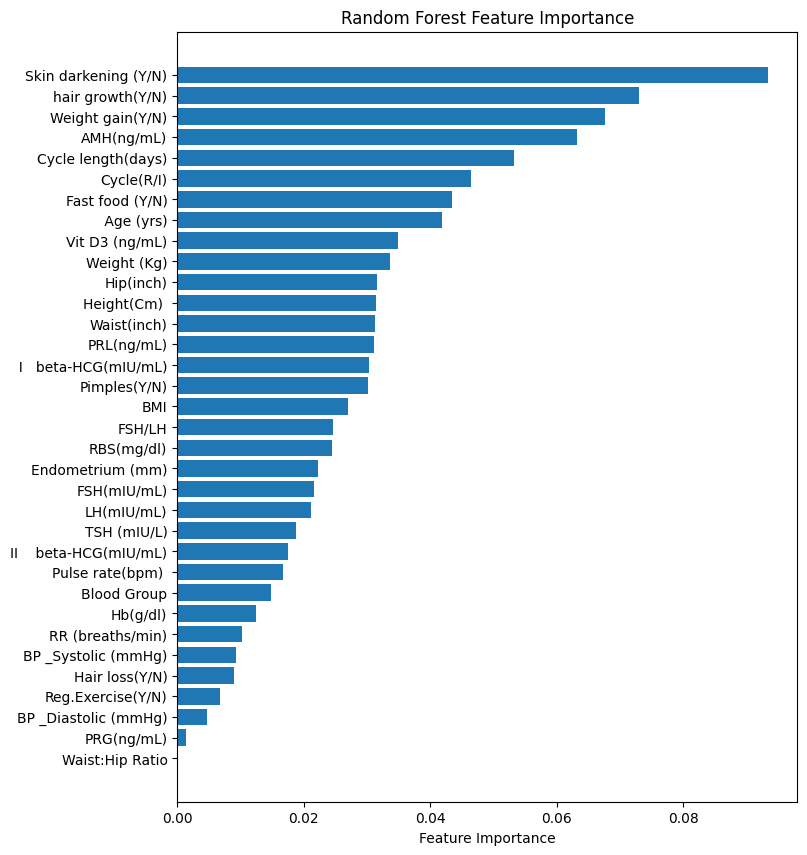

In [18]:
importances = model.feature_importances_
features = x.columns

indices = np.argsort(importances)

plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

**Count Plot (PCOS vs Non-PCOS)**

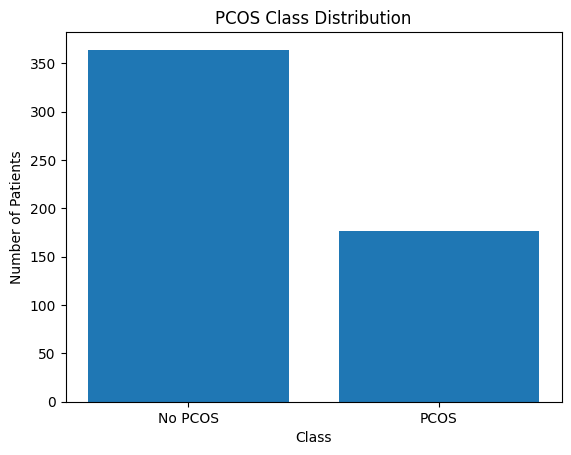

In [19]:
pcos_counts = pcos['PCOS (Y/N)'].value_counts()

plt.figure()
plt.bar(['No PCOS', 'PCOS'], pcos_counts)
plt.title("PCOS Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.show()


**Mean Comparison Bar Graph**

Shows which features influence PCOS

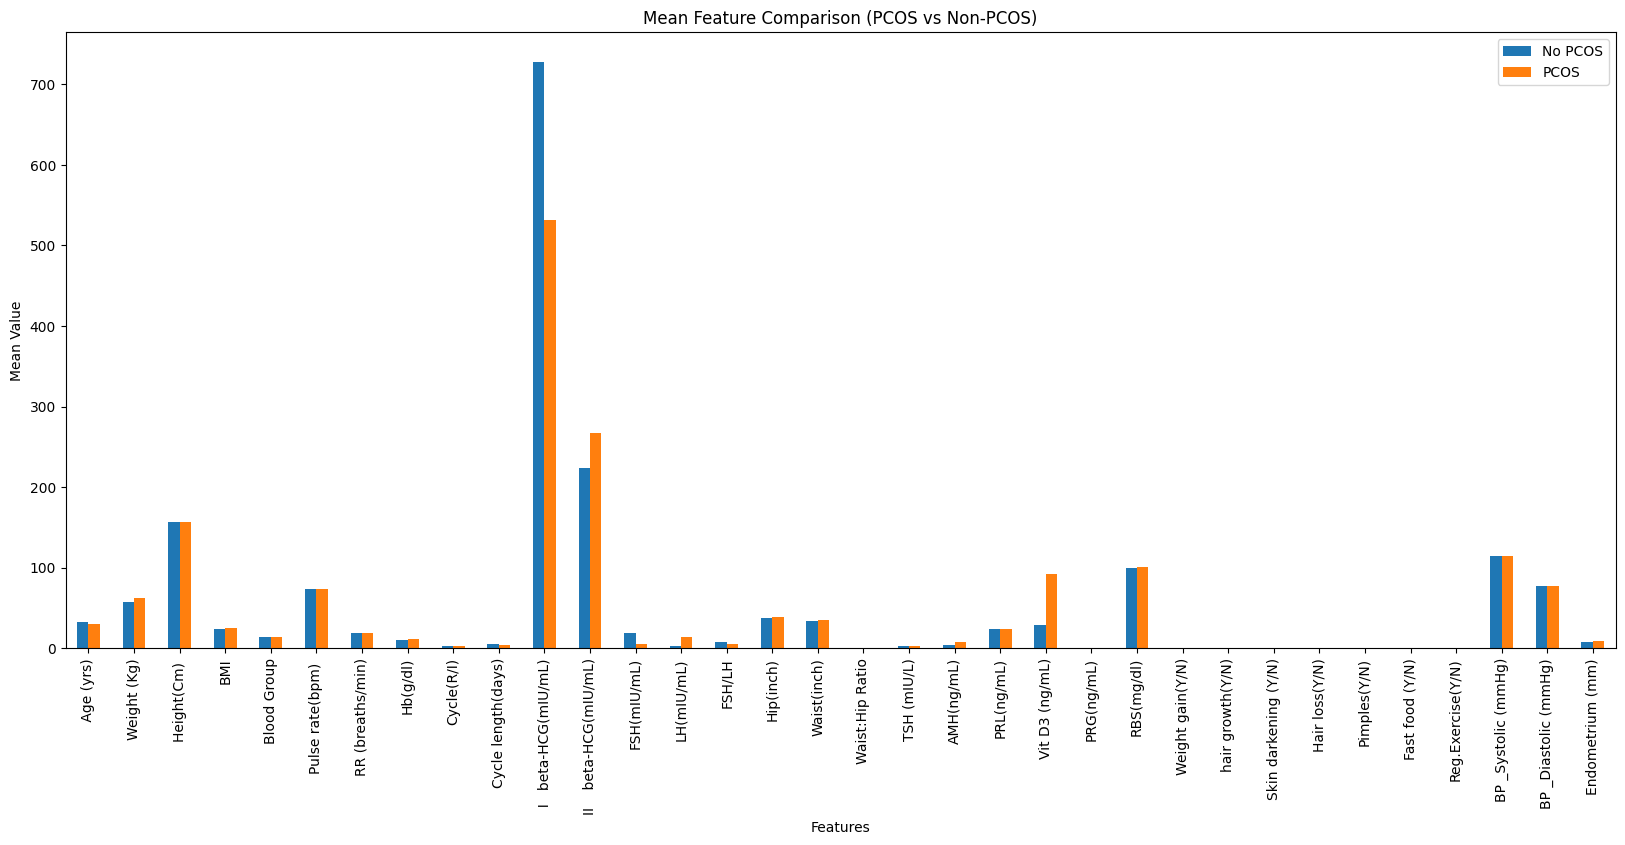

In [20]:
mean_values = pcos.groupby('PCOS (Y/N)').mean()

mean_values.T.plot(kind='bar', figsize=(20, 8))
plt.title("Mean Feature Comparison (PCOS vs Non-PCOS)")
plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=90)
plt.legend(["No PCOS", "PCOS"])
plt.show()


In [21]:
import pickle

pickle.dump(model, open("pcos_rf_model.pkl", "wb"))

In [22]:
pip install flask numpy pickle-mixin

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: flask in c:\users\akhil\appdata\local\programs\python\python310\lib\site-packages (3.1.1)

